In [ ]:
# Import essential Python libraries
import pandas as pd                     # For data handling
import numpy as np                      # For numerical operations
import seaborn as sns                   # For quick visualization
import matplotlib.pyplot as plt         # For plotting
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.ensemble import RandomForestClassifier   # Random Forest model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metrics

In [ ]:
# --- Upload Loan prediction dataset to Colab ---
from google.colab import files
uploaded = files.upload()   # Choose train.csv you downloaded

import pandas as pd

# Load into DataFrame
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
print("Columns:", df.columns.tolist())

print("\nPreview:")
print(df.head())

# Quick info
print("\nInfo:")
print(df.info())

Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN (1).csv
Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv
Dataset loaded successfully with 614 rows and 13 columns.
Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Preview:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508

In [ ]:
# Cell 3: Get basic info (column names, data types, null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# ------------------------------------------------------------
# Step X: Count numeric and categorical columns in Loan Dataset
# ------------------------------------------------------------

# Numeric columns = int or float types (e.g., ApplicantIncome, LoanAmount)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns = all non-numeric (e.g., Gender, Married, Education, etc.)
cat_cols = df.select_dtypes(exclude=["int64", "float64"]).columns

# Display counts and lists
print("🔢 Number of Numeric Columns:", len(num_cols))
print(num_cols.tolist())

print("\n🔤 Number of Categorical Columns:", len(cat_cols))
print(cat_cols.tolist())

🔢 Number of Numeric Columns: 5
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

🔤 Number of Categorical Columns: 8
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [ ]:
# Cell 4: Quick statistics for numeric columns
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Cell 5: Count missing values column-wise
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# ------------------------------------------------------------
# Step X: Explore categorical columns in Loan Prediction dataset
# ------------------------------------------------------------

# Select categorical (non-numeric) columns
cat_cols = df.select_dtypes(exclude=["int64", "float64"]).columns

# Loop through each categorical column and print its value counts
for col in cat_cols:
    print(f"\n📌 Column: {col}")
    print(df[col].value_counts(dropna=False))  # dropna=False → includes missing values


📌 Column: Loan_ID
Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 614, dtype: int64

📌 Column: Gender
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

📌 Column: Married
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

📌 Column: Dependents
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

📌 Column: Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

📌 Column: Self_Employed
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

📌 Column: Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

📌 Column: Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


📊 Loan Status Distribution (%):
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


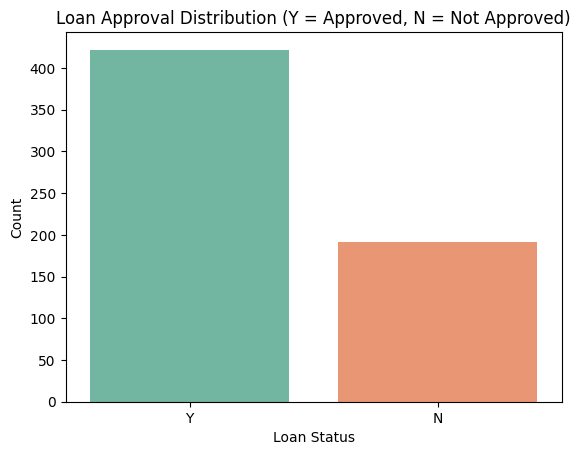

In [ ]:
# ------------------------------------------------------------
# Step X: Check Loan Status distribution
# ------------------------------------------------------------
loan_status_counts = df['Loan_Status'].value_counts(normalize=True) * 100

print("📊 Loan Status Distribution (%):")
print(loan_status_counts)

# Quick visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Loan_Status', palette="Set2")
plt.title("Loan Approval Distribution (Y = Approved, N = Not Approved)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

In [ ]:
# ------------------------------------------------------------
# Step X: Identify numeric columns in Loan Prediction dataset
# ------------------------------------------------------------

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("🔢 Numeric columns:")
print(num_cols.tolist())

🔢 Numeric columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [ ]:
# ------------------------------------------------------------
# Step X: Explore each numeric column in Loan Prediction dataset
# ------------------------------------------------------------

for col in num_cols:
    print(f"\n📊 Column: {col}")
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isnull().sum())
    print("Mean:", round(df[col].mean(), 2))
    print("Median:", round(df[col].median(), 2))
    print("Std Dev:", round(df[col].std(), 2))
    print("Min:", df[col].min(), "Max:", df[col].max())


📊 Column: ApplicantIncome
Unique values: 505
Missing values: 0
Mean: 5403.46
Median: 3812.5
Std Dev: 6109.04
Min: 150 Max: 81000

📊 Column: CoapplicantIncome
Unique values: 287
Missing values: 0
Mean: 1621.25
Median: 1188.5
Std Dev: 2926.25
Min: 0.0 Max: 41667.0

📊 Column: LoanAmount
Unique values: 203
Missing values: 22
Mean: 146.41
Median: 128.0
Std Dev: 85.59
Min: 9.0 Max: 700.0

📊 Column: Loan_Amount_Term
Unique values: 10
Missing values: 14
Mean: 342.0
Median: 360.0
Std Dev: 65.12
Min: 12.0 Max: 480.0

📊 Column: Credit_History
Unique values: 2
Missing values: 50
Mean: 0.84
Median: 1.0
Std Dev: 0.36
Min: 0.0 Max: 1.0


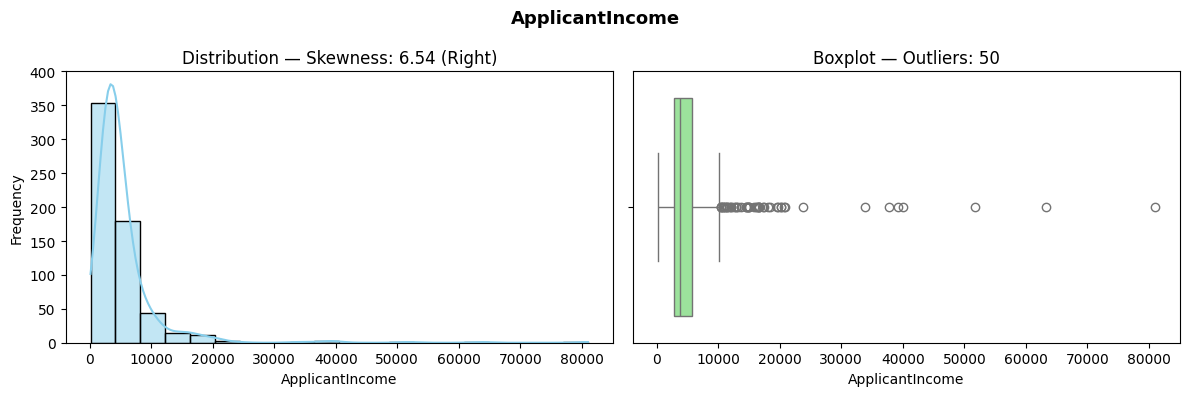

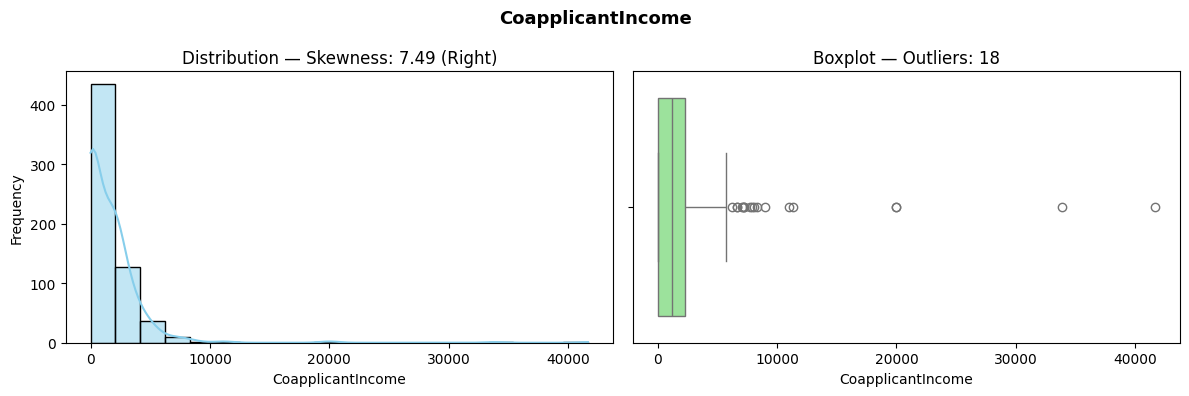

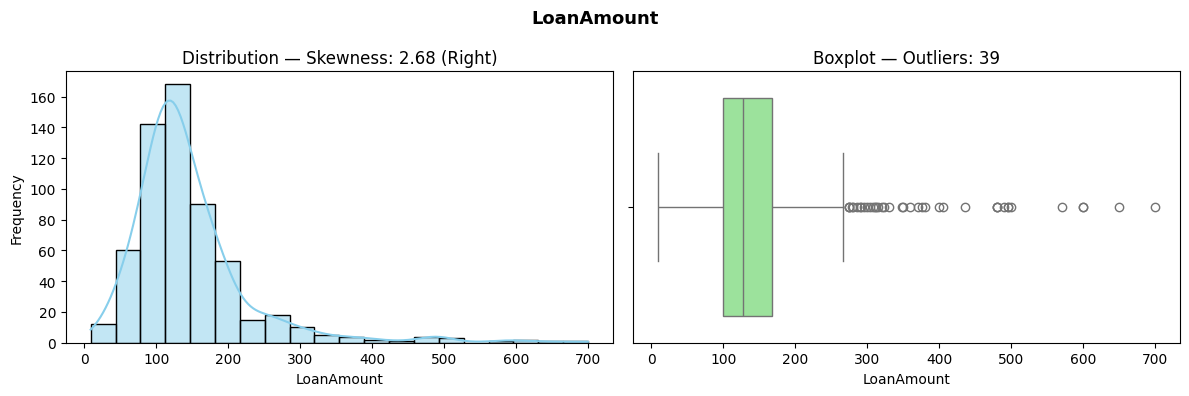

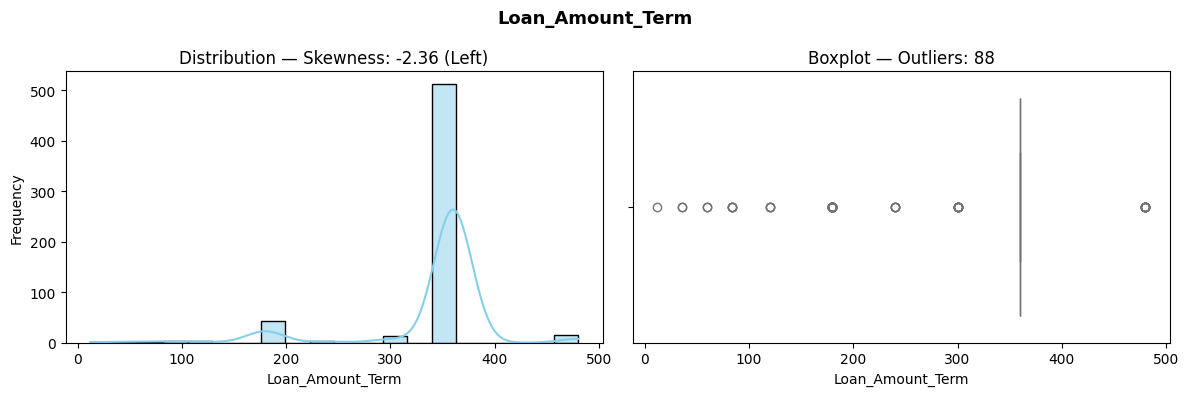

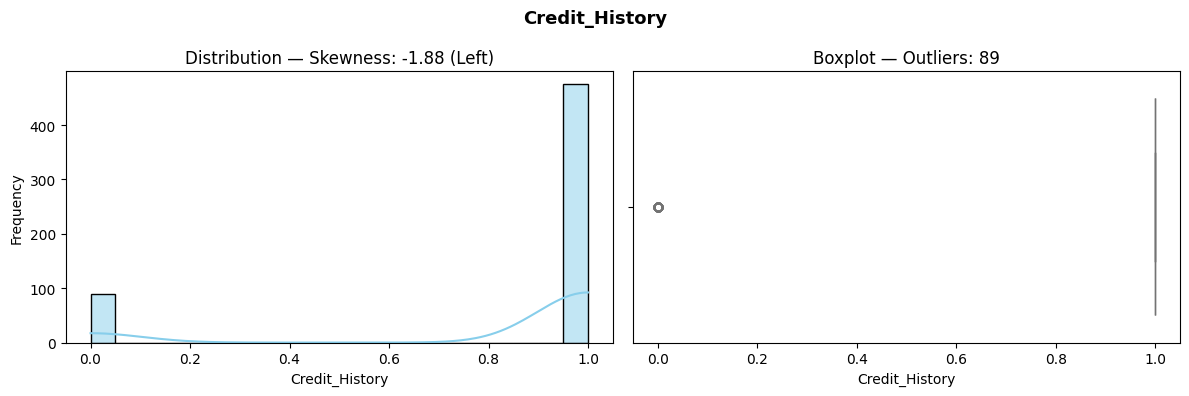

In [ ]:
# ------------------------------------------------------------
# Step X: Visualize numeric columns in Loan Prediction dataset
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Function to count outliers using the IQR rule
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# Plot histograms and boxplots side by side for each numeric column
for col in num_cols:
    data = df[col].dropna()  # drop missing values
    skew_val = data.skew()
    outliers = count_outliers(data)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{col}", fontsize=13, fontweight="bold")

    # Histogram with KDE and skewness info
    sns.histplot(data, bins=20, kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Distribution — Skewness: {skew_val:.2f} "
                      f"({'Right' if skew_val>0 else 'Left' if skew_val<0 else 'Symmetric'})")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # Boxplot showing outliers
    sns.boxplot(x=data, ax=axes[1], color="lightgreen")
    axes[1].set_title(f"Boxplot — Outliers: {outliers}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

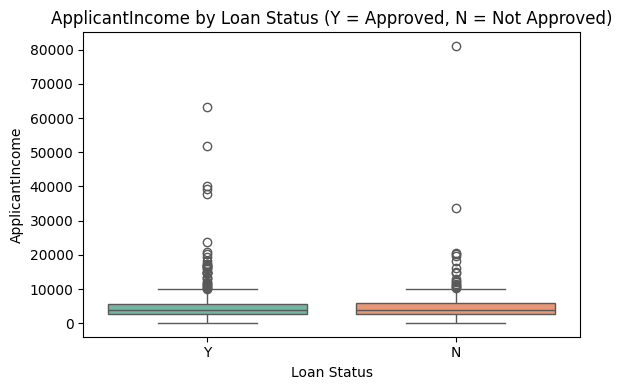

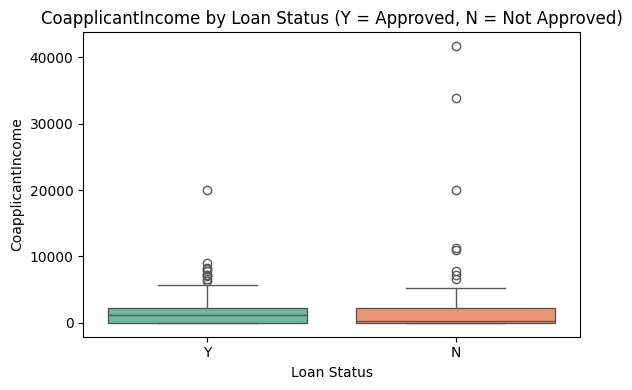

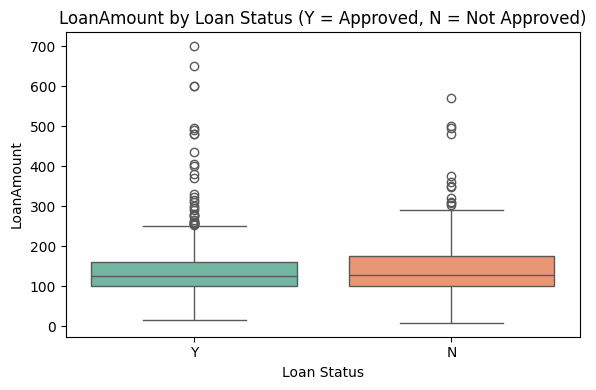

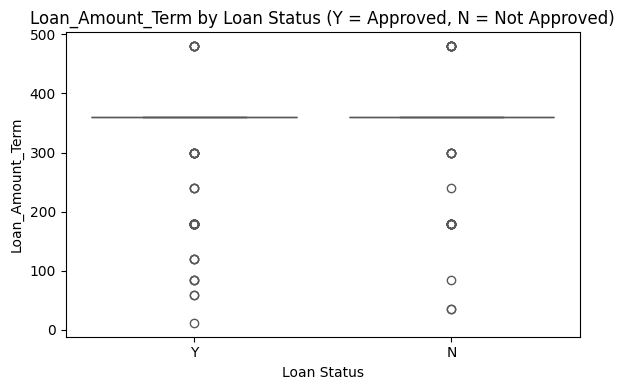

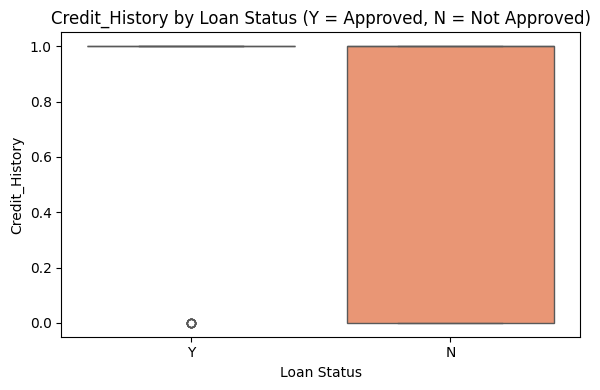

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Select numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Boxplots: Numeric vs Loan_Status
for col in num_cols:
    if col != "Loan_Status":  # skip target itself
        plt.figure(figsize=(6, 4))
        sns.boxplot(
            x="Loan_Status",
            y=col,
            data=df,
            palette="Set2",
            orient="v"
        )
        plt.title(f"{col} by Loan Status (Y = Approved, N = Not Approved)")
        plt.xlabel("Loan Status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

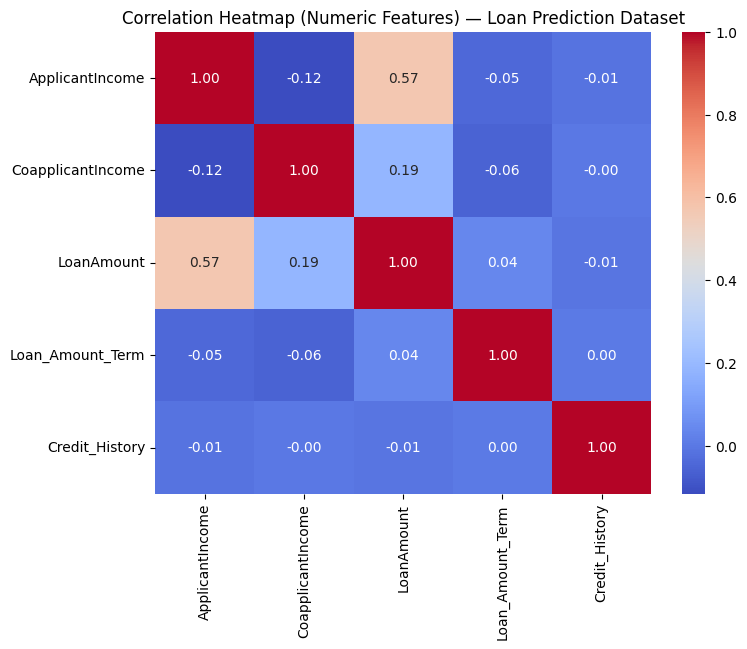

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Step X: Correlation Heatmap for Numeric Features
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features) — Loan Prediction Dataset")
plt.show()

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# Step 1: Load Loan Prediction train and test datasets
# ------------------------------------------------------------

train = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
test = pd.read_csv("test_Y3wMUE5_7gLdaTN.csv")

# Row counts
row_count_train = len(train)
row_count_test = len(test)

print(f"There are {row_count_train} records in the TRAIN dataset.")
print("Train columns:", train.columns.tolist())

print(f"\nThere are {row_count_test} records in the TEST dataset.")
print("Test columns:", test.columns.tolist())


There are 614 records in the TRAIN dataset.
Train columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

There are 367 records in the TEST dataset.
Test columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [ ]:
# ------------------------------------------------------------
# Step 2: Encode categorical columns with simple label mapping
# ------------------------------------------------------------

# Replace categorical string values with numeric codes in both train and test datasets

# Gender: Male=1, Female=2
train['Gender'] = train['Gender'].replace({'Male': 1, 'Female': 2})
test['Gender'] = test['Gender'].replace({'Male': 1, 'Female': 2})

# Married: Yes=1, No=0
train['Married'] = train['Married'].replace({'Yes': 1, 'No': 0})
test['Married'] = test['Married'].replace({'Yes': 1, 'No': 0})

# Dependents: 0=0, 1=1, 2=2, 3+=3
train['Dependents'] = train['Dependents'].replace({'0': 0, '1': 1, '2': 2, '3+': 3})
test['Dependents'] = test['Dependents'].replace({'0': 0, '1': 1, '2': 2, '3+': 3})


# Education: Graduate=1, Not Graduate=0
train['Education'] = train['Education'].replace({'Graduate': 1, 'Not Graduate': 0})
test['Education'] = test['Education'].replace({'Graduate': 1, 'Not Graduate': 0})

# Self_Employed: Yes=1, No=0
train['Self_Employed'] = train['Self_Employed'].replace({'Yes': 1, 'No': 0})
test['Self_Employed'] = test['Self_Employed'].replace({'Yes': 1, 'No': 0})

# Property_Area: Rural=1, Semiurban=2, Urban=3
train['Property_Area'] = train['Property_Area'].replace({'Rural': 1, 'Semiurban': 2, 'Urban': 3})
test['Property_Area'] = test['Property_Area'].replace({'Rural': 1, 'Semiurban': 2, 'Urban': 3})

# Target column (Loan_Status): Y=1, N=0 (only in train dataset)
train['Loan_Status'] = train['Loan_Status'].replace({'Y': 1, 'N': 0})

print("✅ Categorical values successfully encoded into numeric form.")

✅ Categorical values successfully encoded into numeric form.


In [ ]:
## ---------------------------------------------------------
##  Convert categories to numbers & prepare data for modeling
## ---------------------------------------------------------

# 🎯 Select feature columns (independent variables)
# We'll use key predictors that influence loan approval
# These include both categorical (already encoded) and numeric features.

feature_cols = [
    'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
    'Loan_Amount_Term', 'Credit_History', 'Property_Area'
]

# Extract features (X) and target (y) from the training dataset
dt_train_x = train[feature_cols].values
dt_train_y = train['Loan_Status'].values   # Target variable (1 = Approved, 0 = Not Approved)

# Prepare test features (no Loan_Status in test data)
test_x = test[feature_cols].values

print("✅ Feature and target data prepared successfully!")
print("Training feature shape:", dt_train_x.shape)
print("Test feature shape:", test_x.shape)


✅ Feature and target data prepared successfully!
Training feature shape: (614, 11)
Test feature shape: (367, 11)


In [ ]:
# ------------------------------------------------------------
# Step 4: Build and train the Random Forest model
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

# Why these settings?
# - n_estimators=300 → more trees = better averaging & stability
# - max_depth=None → trees grow until pure (RF handles overfitting well)
# - class_weight='balanced' → accounts for Loan_Status imbalance (Approved vs Not Approved)
# - random_state=42 → ensures reproducibility
# - n_jobs=-1 → uses all CPU cores for speed

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ✅ Fit the model on training data
rf_clf.fit(dt_train_x, dt_train_y)

print("✅ Random Forest training complete!")
print(f"Number of features used: {dt_train_x.shape[1]}")

✅ Random Forest training complete!
Number of features used: 11


In [ ]:
# ------------------------------------------------------------
# Split training data into training and validation sets
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Split dt_train_x and dt_train_y into training and validation sets
# Using a test_size of 0.2 means 20% of the data will be used for validation
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    dt_train_x,
    dt_train_y,
    test_size=0.2,
    random_state=42,
    stratify=dt_train_y # Stratify to maintain the proportion of target variable in both splits
)

print("✅ Training data split into training and validation sets successfully!")
print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Validation target shape: {y_test.shape}")

✅ Training data split into training and validation sets successfully!
Training features shape: (491, 11)
Validation features shape: (123, 11)
Training target shape: (491,)
Validation target shape: (123,)


✅ Model Accuracy: 1.0000

🧮 Confusion Matrix:
                          Pred: Not Approved (0)  Pred: Approved (1)
Actual: Not Approved (0)                      38                   0
Actual: Approved (1)                           0                  85


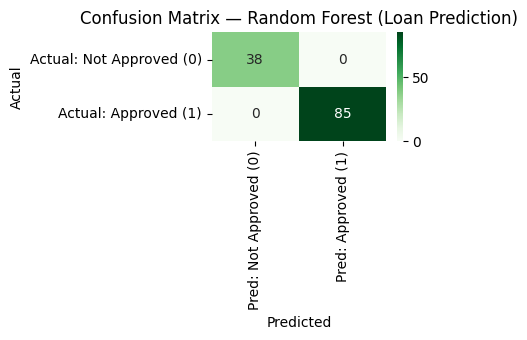


📊 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        38
           1     1.0000    1.0000    1.0000        85

    accuracy                         1.0000       123
   macro avg     1.0000    1.0000    1.0000       123
weighted avg     1.0000    1.0000    1.0000       123

🧭 ROC-AUC Score: 1.0000


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Not Approved (0)', 'Actual: Approved (1)'],
                     columns=['Pred: Not Approved (0)', 'Pred: Approved (1)'])
print("\n🧮 Confusion Matrix:")
print(cm_df)

# Plot CM
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Random Forest (Loan Prediction)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"🧭 ROC-AUC Score: {roc_auc:.4f}")

✅ Model Accuracy: 1.0000

🧮 Confusion Matrix:
                          Pred: Not Approved (0)  Pred: Approved (1)
Actual: Not Approved (0)                      38                   0
Actual: Approved (1)                           0                  85


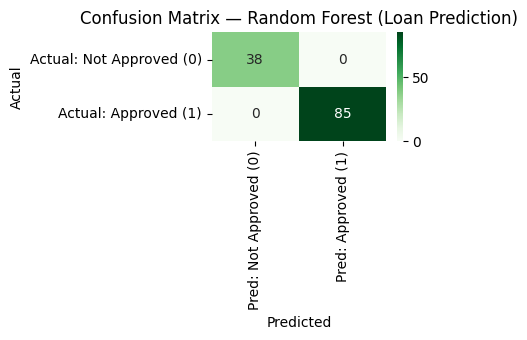


📊 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        38
           1     1.0000    1.0000    1.0000        85

    accuracy                         1.0000       123
   macro avg     1.0000    1.0000    1.0000       123
weighted avg     1.0000    1.0000    1.0000       123

🧭 ROC-AUC Score: 1.0000


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Not Approved (0)', 'Actual: Approved (1)'],
                     columns=['Pred: Not Approved (0)', 'Pred: Approved (1)'])
print("\n🧮 Confusion Matrix:")
print(cm_df)

# Plot CM
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Random Forest (Loan Prediction)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"🧭 ROC-AUC Score: {roc_auc:.4f}")


🏆 Top 10 Important Features Influencing Loan Approval:
              Feature  Importance
9      Credit_History    0.222204
7          LoanAmount    0.203145
5     ApplicantIncome    0.201255
6   CoapplicantIncome    0.120756
2          Dependents    0.052697
10      Property_Area    0.049854
8    Loan_Amount_Term    0.045243
4       Self_Employed    0.029388
0              Gender    0.026312
1             Married    0.025228


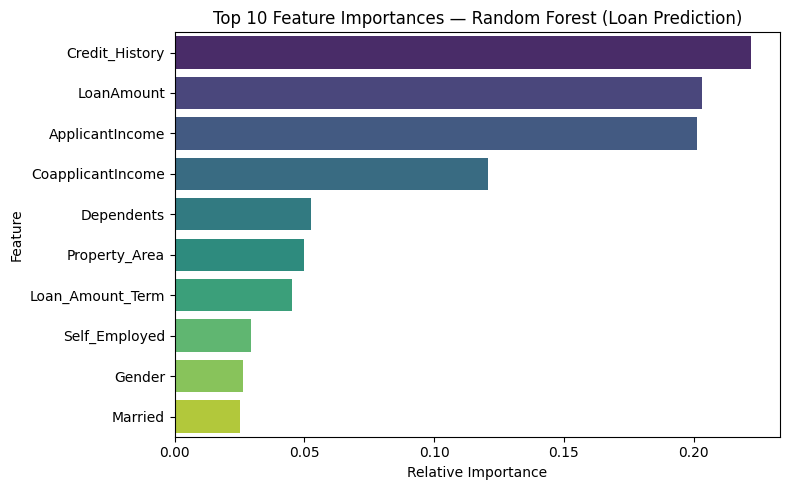

In [ ]:
# ------------------------------------------------------------
# Step 6: Feature Importance (which variables mattered most?)
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Get feature importances from the trained Random Forest model
importances = rf_clf.feature_importances_

# ✅ Combine with feature names
# Use the feature_cols list for column names as X_train is a numpy array
feature_importance_df = pd.DataFrame({
    "Feature": feature_cols, # Use the feature_cols list
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# ✅ Display the top 10 most important features
print("🏆 Top 10 Important Features Influencing Loan Approval:")
print(feature_importance_df.head(10))

# ✅ Plot the feature importances
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Feature Importances — Random Forest (Loan Prediction)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Step 7: Hyperparameter Tuning using RandomizedSearchCV
# ------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import classification_report, accuracy_score

# 🎯 Define parameter distributions (Random Search is faster than full Grid Search)
param_dist = {
    'n_estimators': randint(100, 600),          # number of trees
    'max_depth': [None, 5, 10, 20, 30],         # maximum tree depth
    'max_features': ['sqrt', 'log2'],           # how many features to consider per split
    'min_samples_split': randint(2, 11),        # min samples to split a node
    'min_samples_leaf': randint(1, 5),          # min samples per leaf
    'bootstrap': [True, False]                  # whether to use bootstrap samples
}

# 🧠 Initialize RandomizedSearchCV for tuning
random_search = RandomizedSearchCV(
    estimator=rf_clf,                 # your RandomForest model from Step 4
    param_distributions=param_dist,
    n_iter=25,                        # number of random combinations
    cv=5,                             # 5-fold cross-validation
    n_jobs=-1,                        # use all cores
    verbose=2,
    random_state=42,
    scoring='accuracy'                # optimize for accuracy
)

# 🚀 Fit RandomizedSearchCV on training data
random_search.fit(X_train, y_train)

# ✅ Display best parameters and CV score
print("✅ Best Parameters Found (RandomizedSearchCV):")
print(random_search.best_params_)
print(f"🎯 Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

# 🏆 Evaluate tuned model on test data
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n📊 Tuned Model Evaluation on Test Set:")
print(classification_report(y_test, y_pred_best, digits=4))
print(f"✅ Test Accuracy after tuning: {accuracy_score(y_test, y_pred_best):.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Best Parameters Found (RandomizedSearchCV):
{'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 463}
🎯 Best Cross-Validation Accuracy: 0.7862

📊 Tuned Model Evaluation on Test Set:
              precision    recall  f1-score   support

           0     0.7188    0.6053    0.6571        38
           1     0.8352    0.8941    0.8636        85

    accuracy                         0.8049       123
   macro avg     0.7770    0.7497    0.7604       123
weighted avg     0.7992    0.8049    0.7998       123

✅ Test Accuracy after tuning: 0.8049


In [ ]:
# ------------------------------------------------------------
# Step 8: Save and reload the trained Random Forest model
# ------------------------------------------------------------
import joblib

# 💾 Save the tuned or baseline Random Forest model
joblib.dump(best_rf, "loan_prediction_random_forest_model.pkl")
print("💾 Model saved successfully as 'loan_prediction_random_forest_model.pkl'")

# 🔁 Reload the saved model (useful for future predictions or deployment)
loaded_rf = joblib.load("loan_prediction_random_forest_model.pkl")

# 🧠 Test the reloaded model on a few test samples
sample_pred = loaded_rf.predict(X_test[:5])
print("\n🔁 Sample predictions from reloaded Loan Prediction model:")
print(sample_pred)

# Optional: Compare with actual labels
print("\n🎯 Actual values:")
print(y_test[:5]) # Removed .values here

💾 Model saved successfully as 'loan_prediction_random_forest_model.pkl'

🔁 Sample predictions from reloaded Loan Prediction model:
[0 1 1 1 1]

🎯 Actual values:
[0 1 1 1 1]
